# Preprocess Data

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

## Clean Data

In [2]:
df = pd.read_excel('HFpEF-research3.2.xlsx', skiprows=[1,2,3,4,5,6,7,8,9])

In [3]:
df = df.drop(columns=['Unnamed: 0', 'time to mortality after diagnosis', 'time to HF hospitalization after diagnosis', 'SSRI', 'HF re-hospitalization'])

In [5]:
df.columns

Index(['Age', 'Sex', 'Cr', 'GFR', 'CKD stage', 'smoke', 'BMI', 'BSA', 'DM',
       'Insulin', 'AF', 'SBP', 'DBP', 'MAP', 'PP', '1/2SBP', 'wide PP', 'HR',
       'ACE-i', 'ARB', 'ARNI', 'betablocker', 'Aspirin', 'SGLT2i', 'MRA', 'MI',
       'stroke', 'COPD', 'NYHA', 'edema', 'Death', 'CV death',
       'Major cardiac events', 'NTProBNP', 'medial a'', 'medial E'',
       'lateral E'', 'average e/E'', 'lateral e/E'', 'E/A', 'Mitral E/e'',
       'TR Vmax', 'RWT', 'LV mass index', 'LVH', 'LAVI', 'LACI', 'LA diameter',
       'LVEF'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 49 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   200 non-null    int64  
 1   Sex                   200 non-null    int64  
 2   Cr                    200 non-null    float64
 3   GFR                   200 non-null    float64
 4   CKD stage             200 non-null    int64  
 5   smoke                 21 non-null     float64
 6   BMI                   188 non-null    float64
 7   BSA                   198 non-null    float64
 8   DM                    200 non-null    int64  
 9   Insulin               200 non-null    int64  
 10  AF                    200 non-null    int64  
 11  SBP                   200 non-null    int64  
 12  DBP                   200 non-null    int64  
 13  MAP                   200 non-null    float64
 14  PP                    200 non-null    int64  
 15  1/2SBP                2

In [7]:
df = df.copy()

In [8]:
df['NTProBNP'].unique()

array([4169, 732, nan, 3493, 4060, 2851, 1017, '>35,000', 942, 4292, 1487,
       451.9, 2351, 3841, 458.2, 976, 4382, 1153, 1316, '> 35000', 436.1,
       12887, 894, 15026, 33177, 4167, 9860, 858.1, 17796, 6859, 11291,
       25202, 3011, 7348, 625.7, 21777, 1274, 1040, 4877, 1051, 1196,
       25766, 3195, 1362, 65.7, 6720, 29430, 478.4, 8131, 4792, 8677,
       6620, 23893, 1042, 1608, 41.74, 15119, 2636, 1711, 1293, 1490,
       7924, 3382, 963, 348, 25094, 5944, 2114, 721, 1590, 2011, 675.9,
       4204, 293, 235.9, 8.32, 2176, 137, 178.6, 703.8, 9351, 1030, 140,
       164, 2251, 8600, 171.6, 195.9, 13624, 7633, 501.9, 3227, 2745,
       4242, 132.5, 3468, 1678, 309, 213.9, 3812, 4633, 5153, 2932, 5864,
       125, 1375, 3449, 6181, 141, '>35000', 1114, 1197, 3245, 862.7,
       125.1, 1654, 2134, 8190, 209, 18122, 2733], dtype=object)

In [9]:
df.loc[df['NTProBNP']=='>35,000','NTProBNP'] = 35001
df.loc[df['NTProBNP']=='> 35000','NTProBNP'] = 35001
df.loc[df['NTProBNP']=='>35000','NTProBNP'] = 35001

In [10]:
df['NTProBNP'] = df['NTProBNP'].astype('float')

In [11]:
df['LV mass index'].unique()

array([141.14, 84.6, 252, 129.7, 148.6, 143, 92.6, 98, 112.2, 97.1, 113.1,
       164, 94.7, 146.3, 73, 89.9, nan, 110.1, 76.4, 116.6, 119.3, 66.3,
       106, 47.4, 87.7, 94.6, 126, 71.6, 113, 117.8, 356.6, 114, 116.25,
       97.9, 157, 91.4, 204.9, 97.2, 69.1, 120.5, 95, 83.4, 102.7, 121.7,
       105.2, 130.1, 74.7, 216, 197.1, 98.3, 68.3, 130, 73.5, 126.4,
       119.8, 131.4, 86.5, 64.7, 90.2, 66.7, 174.7, 150, 53.8, 123.1,
       114.6, 107.6, 132.2, 239, 69.5, 67.5, 182.5, 117.4, 88.8, 103.4,
       212.9, 55.6, 122.3, 141.8, 129.5, 150.8, 123.7, 59.5, 148.1, 83.1,
       158.2, 116.1, 203.3, 129.9, 202.7, 126.7, 157.6, 131.7, 75.7, 75.6,
       153, 83, 94.4, 171.7, 90.4, 107.5, 67.8, 63, 130.9, 99.4, 188, 158,
       113.8, 145.4, 171.9, 255.6, 212.1, 96, 93.8, 113.3, 113.2, 121,
       112.5, 143.5, 167.4, 228, 145, '183,7', 159, 81.9, 79.9, 116.2,
       128.4, 196, 86.8, 88.6, 202.2, 127.5, 119, 132.3, 103, 179, 91.7,
       80.5, 75.5, 92.3, 185.6, 119.6, 81.2, 132.4, 75.

In [12]:
df.loc[df['LV mass index']=='183,7','LV mass index'] = 183.7

In [13]:
df['LV mass index'] = df['LV mass index'].astype('float')

In [14]:
df.describe()

,Age,Sex,Cr,GFR,CKD stage,smoke,BMI,BSA,DM,Insulin,...,E/A,Mitral E/e',TR Vmax,RWT,LV mass index,LVH,LAVI,LACI,LA diameter,LVEF
count,200.000000,200.000000,200.000000,200.000000,200.000000,21.0,188.000000,198.000000,200.000000,200.000000,...,157.000000,189.000000,197.000000,188.000000,188.000000,191.000000,145.000000,143.000000,106.000000,199.000000
mean,72.045000,1.680000,1.711100,52.293250,2.810000,1.0,26.738830,1.632980,0.560000,0.215000,...,0.944676,18.307566,1.918883,0.689686,123.022287,2.764398,44.120000,4.491799,4.172925,61.743216
std,11.404529,0.467647,1.534721,25.188572,1.043718,0.0,6.846494,0.229433,0.497633,0.411853,...,0.525861,7.732642,1.435453,0.363127,45.292977,1.850175,20.390639,4.063010,0.775072,7.218575
min,31.000000,1.000000,0.550000,2.000000,1.000000,1.0,15.400000,1.120000,0.000000,0.000000,...,0.400000,4.290000,0.000000,0.177000,47.400000,0.000000,9.500000,0.000000,2.100000,50.000000
25%,65.000000,1.000000,0.887500,34.750000,2.000000,1.0,22.175000,1.475000,0.000000,0.000000,...,0.600000,12.400000,0.000000,0.420000,91.625000,1.000000,29.400000,1.875088,3.700000,56.000000
50%,74.000000,2.000000,1.140000,54.000000,3.000000,1.0,25.800000,1.600000,1.000000,0.000000,...,0.800000,17.000000,2.520000,0.585000,115.350000,3.000000,40.500000,3.766816,4.100000,61.000000
75%,80.000000,2.000000,1.792500,70.250000,3.000000,1.0,30.575000,1.800000,1.000000,0.000000,...,1.100000,22.400000,3.010000,0.900000,143.875000,4.000000,54.200000,6.618327,4.575000,66.000000
max,97.000000,2.000000,10.000000,108.000000,5.000000,1.0,55.900000,2.300000,1.000000,1.000000,...,4.100000,42.200000,4.550000,2.300000,356.600000,7.000000,140.800000,23.665480,6.200000,82.900000


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 49 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   200 non-null    int64  
 1   Sex                   200 non-null    int64  
 2   Cr                    200 non-null    float64
 3   GFR                   200 non-null    float64
 4   CKD stage             200 non-null    int64  
 5   smoke                 21 non-null     float64
 6   BMI                   188 non-null    float64
 7   BSA                   198 non-null    float64
 8   DM                    200 non-null    int64  
 9   Insulin               200 non-null    int64  
 10  AF                    200 non-null    int64  
 11  SBP                   200 non-null    int64  
 12  DBP                   200 non-null    int64  
 13  MAP                   200 non-null    float64
 14  PP                    200 non-null    int64  
 15  1/2SBP                2

In [16]:
df['smoke'] = df['smoke'].fillna(0)
df['BMI'] = df['BMI'].fillna(df['BMI'].mean())
df['BSA'] = df['BSA'].fillna(df['BSA'].mean())
df['HR'] = df['HR'].fillna(df['HR'].mean().round())
df['stroke'] = df['stroke'].fillna(0)

In [17]:
df['BSA'].mean()

1.632979797979798

In [18]:
df['BMI'].mean()

26.738829787234046

In [19]:
df['HR'].mean().round()

77.0

LA diameter = 10.7 + 0.27 * LAVI + 10.6 * BSA

So

LAVI = (LA diameter - 10.6 * BSA - 10.7) / 0.27

https://onlinelibrary.wiley.com/doi/full/10.1111/echo.14943

In [20]:
idx = df['LA diameter'].isnull()
df.loc[idx, 'LA diameter'] = 10.7 + (0.27 * df['LAVI'][idx]) + (10.6 * df['BSA'][idx])

In [21]:
idx = df['LAVI'].isnull()
df.loc[idx, 'LAVI'] = (df['LA diameter'][idx] - (10.6 * df['BSA'][idx]) - 10.7) / 0.27

In [22]:
df = df.fillna(0)

## Displaying

In [62]:
lbl_colname= ['Death', 'CV death', 'Major cardiac events']

In [63]:
y = np.array(df[lbl_colname])
X = df.drop(lbl_colname, axis = 1)
# X = X[['Age', 'Sex', 'Cr', 'GFR', 'CKD stage', 'AF', 'MAP', 'PP', 'NTProBNP', "medial a'", "medial E'", 'LAVI', 'LA diameter']]
# Saving feature names for later use
feature_list = list(X.columns)
# # Convert to numpy array
X = np.array(X)

In [64]:
def plot_tsne(X_val, y, lbl_colname):
    f = plt.figure()
    plt.scatter(X_val[:, 0], X_val[:, 1], cmap=plt.cm.Spectral)
#     plt.xticks([])
#     plt.yticks([])
#     plt.gca().set_aspect('equal')
    fig, axes = plt.subplots(1, len(y[0]), figsize=(15, 4))
    for i in range(len(y[0])):
        scatter = axes[i].scatter(X_val[:, 0], X_val[:, 1], c=y[:,i], cmap=plt.cm.jet, alpha=0.5)
#         axes[i].set_xticks([])
#         axes[i].set_yticks([])
#         axes[i].set_aspect('equal')
        axes[i].legend(scatter.legend_elements()[0], ['No','Yes'], title="Classes")
        axes[i].set_title(f'{lbl_colname[i]}')

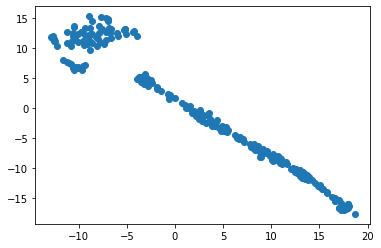

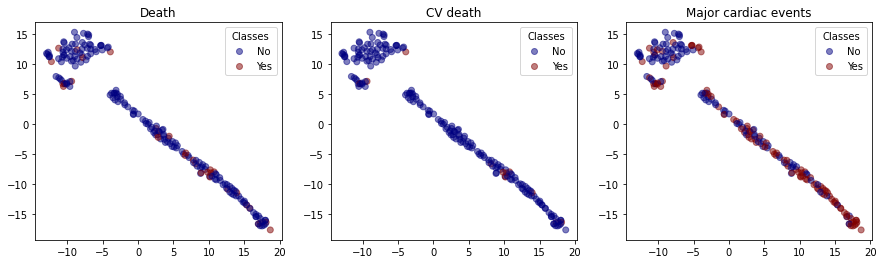

In [65]:
from sklearn.manifold import TSNE
X_embedded = TSNE(n_components=2, init='random').fit_transform(X)
plot_tsne(X_embedded, y, lbl_colname)
plt.savefig("tsne_200.png")

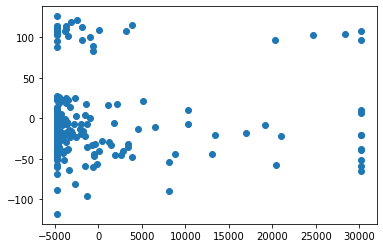

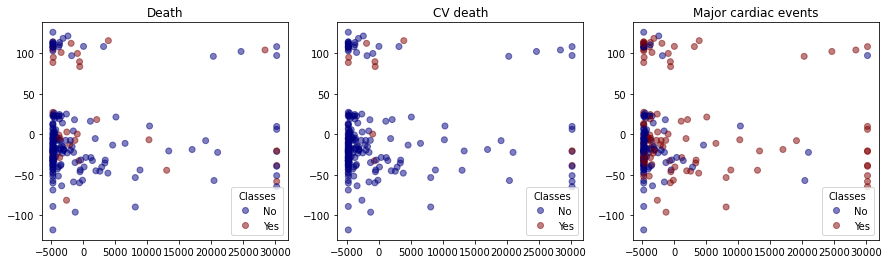

In [66]:
from sklearn.decomposition import PCA
X_pca = PCA(n_components=2).fit_transform(X)
plot_tsne(X_pca, y, lbl_colname)

(array([146.,  19.,   9.,   4.,   2.,   2.,   2.,   3.,   1.,  12.]),
 array([-4766.46372014, -1266.32420761,  2233.81530491,  5733.95481743,
         9234.09432995, 12734.23384247, 16234.37335499, 19734.51286751,
        23234.65238003, 26734.79189255, 30234.93140508]),
 <BarContainer object of 10 artists>)

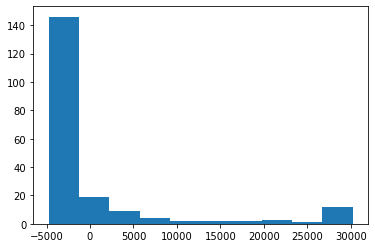

In [67]:
from sklearn.decomposition import PCA
X_pca = PCA(n_components=0.99).fit_transform(X)
plt.hist(X_pca)

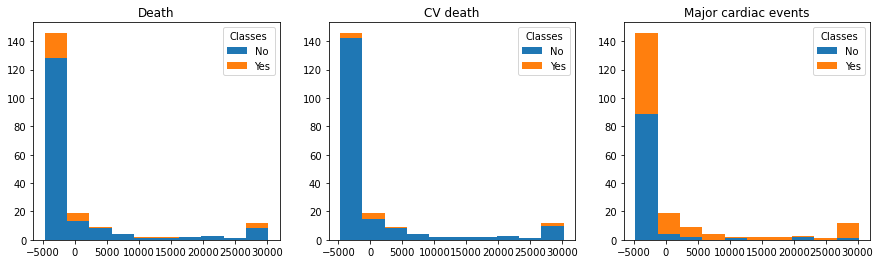

In [68]:
fig, axes = plt.subplots(1, len(y[0]), figsize=(15, 4))
for i in range(len(y[0])):
    hist = axes[i].hist([X_pca[y[:,i]==0].ravel(),X_pca[y[:,i]==1].ravel()], stacked=True)
    axes[i].legend(['No','Yes'], title="Classes")
    axes[i].set_title(f'{lbl_colname[i]}')
plt.savefig("pca_200.png")

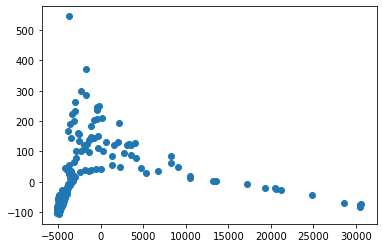

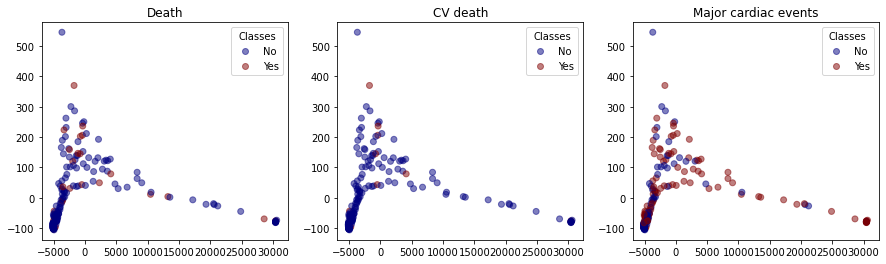

In [69]:
from sklearn.manifold import Isomap
X_iso = Isomap(n_neighbors=10, n_components=2).fit_transform(X)
plot_tsne(X_iso, y, lbl_colname)

In [70]:
from sklearn.cluster import SpectralClustering
clustering = SpectralClustering(n_clusters=3,eigen_solver='arpack',affinity="nearest_neighbors",
                                random_state=0).fit(X)
clustering.labels_

array([1, 2, 0, 2, 1, 0, 2, 2, 1, 0, 2, 1, 0, 2, 2, 2, 0, 1, 0, 2, 2, 0,
       1, 0, 2, 2, 1, 1, 2, 1, 1, 1, 0, 0, 2, 1, 1, 0, 1, 1, 2, 0, 1, 1,
       0, 1, 0, 0, 1, 1, 2, 1, 2, 0, 1, 2, 2, 1, 2, 0, 2, 1, 2, 0, 1, 2,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 2, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 2,
       2, 0, 1, 2, 1, 2, 0, 2, 2, 1, 0, 0, 2, 2, 2, 1, 1, 2, 2, 2, 2, 0,
       2, 1, 2, 2, 0, 2, 2, 0, 0, 2, 0, 2, 0, 0, 0, 1, 2, 2, 2, 0, 2, 0,
       0, 0, 0, 1, 0, 2, 2, 1, 0, 0, 1, 2, 2, 2, 0, 2, 0, 1, 1, 2, 2, 2,
       0, 0, 2, 0, 0, 2, 1, 1, 0, 1, 0, 2, 1, 2, 2, 2, 1, 2, 0, 0, 1, 0,
       2, 0, 0, 2, 0, 0, 0, 0, 2, 0, 2, 0, 1, 0, 2, 1, 0, 2, 2, 1, 2, 1,
       0, 2])

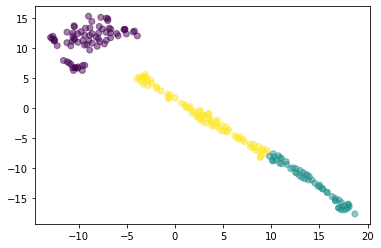

In [74]:
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=clustering.labels_, alpha=0.5)
plt.savefig("spectral_clustering_200.png")

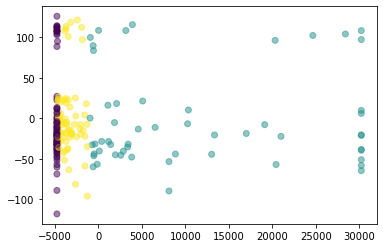

In [31]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clustering.labels_, alpha=0.5)

In [76]:
from sklearn.cluster import SpectralClustering
clustering = SpectralClustering(n_clusters=2,eigen_solver='arpack',affinity="nearest_neighbors",
                                random_state=0).fit(X)
clustering.labels_

array([1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1,
       0, 1])

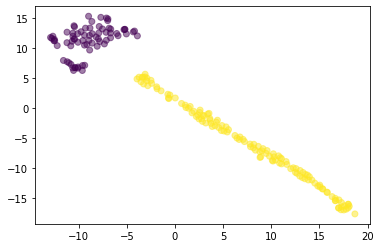

In [77]:
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], c=clustering.labels_, alpha=0.5)
plt.savefig("spectral_clustering_200.png")

## Normalized Input

In [34]:
from sklearn import preprocessing
scaler = preprocessing.MinMaxScaler().fit(X)
X_scaled = scaler.transform(X)

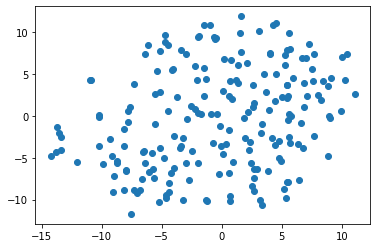

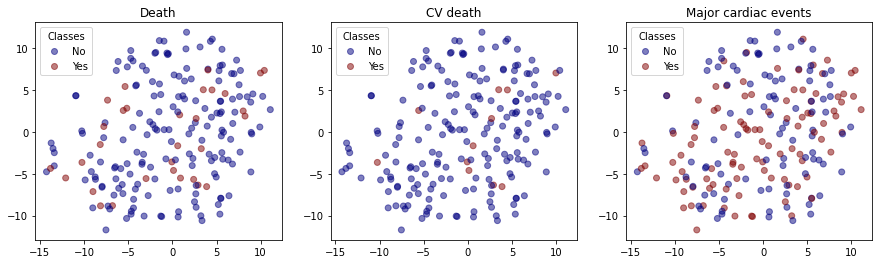

In [35]:
X_embedded = TSNE(n_components=2, init='random').fit_transform(X_scaled)
plot_tsne(X_embedded, y, lbl_colname)

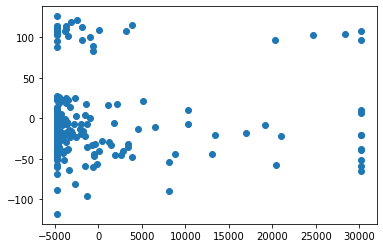

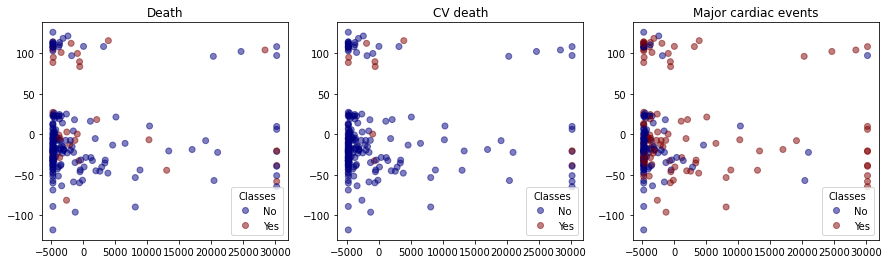

In [36]:
X_pca = PCA(n_components=2).fit_transform(X)
plot_tsne(X_pca, y, lbl_colname)

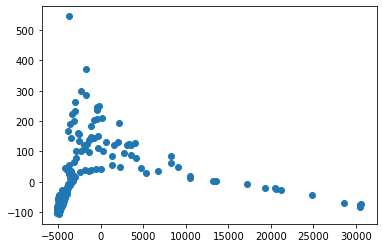

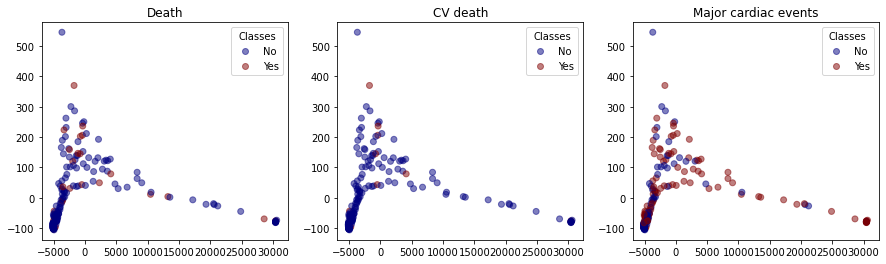

In [37]:
X_iso = Isomap(n_neighbors=10, n_components=2).fit_transform(X)
plot_tsne(X_iso, y, lbl_colname)